# Serotonergic reference dataset quality screen

## tl;dr

GSE76381 is a usable **independent human serotonergic positive control** after deterministic Ensembl translation: 1,977 cells, 16,105 matched genes, complete required metadata, and strong TPH2/SLC6A4/FEV enrichment in the published `hSert` class. The 14 positive cells are too few to be the sole probability-calibration training set. GSE226494 provides valid zebrafish count matrices, but its public release lacks a barcode-level final cell-type table, so the published ISN labels cannot yet be treated as recovered ground truth.


## Context & Methods

This notebook audits candidate public positive-reference datasets for calibrating SAMap evidence. The intended grain is one cell by one gene, with a published per-cell biological label and sample identifier.

### Key assumptions

- Published author labels are used as reference evidence, not as proof of identical evolutionary cell identity.
- Exact unique gene-symbol matches to the project's human Ensembl vocabulary are acceptable; ambiguous symbols are excluded.
- Generated `.h5ad` and raw downloads are local-only and are not committed to Git.

Sources: [human GEO GSE76381](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE76381), [human study](https://pmc.ncbi.nlm.nih.gov/articles/PMC5055122/), [zebrafish GEO GSE226494](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE226494), [zebrafish study](https://pmc.ncbi.nlm.nih.gov/articles/PMC10387610/), and [authors' zebrafish code](https://github.com/Fushun-Chen/Sox1a_scRNA).


## Data

Load the compact repository QA tables and the locally generated human AnnData object.

In [1]:
from pathlib import Path
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

screen = pd.read_csv(ROOT / "public_results/serotonergic_reference_dataset_screen.csv")
quality = pd.read_csv(ROOT / "public_results/human_serotonergic_reference_quality.csv")
human_path = ROOT / "data/processed/human_serotonergic_GSE76381.h5ad"
assert human_path.exists(), "Run workflow/scripts/prepare_human_serotonergic_reference.py first"
human = ad.read_h5ad(human_path)
screen

,organism,accession,reference_population,technology,processed_counts,cell_labels,gene_ids,current_status,key_limitation
0,human,GSE76381,Sert cells from fetal ventral midbrain,STRT-seq,yes,yes,gene symbols,usable after Ensembl translation,developmental tissue and plate-based protocol
1,zebrafish,GSE226494,intraspinal serotonergic neurons from sox1a li...,10x Genomics,yes,no barcode-level labels published with GEO,Ensembl IDs and symbols,counts validated; labels pending,developmental spinal population and absent pub...


## Results

### 1. Structural quality checks

In [2]:
quality[['check', 'value', 'status', 'interpretation']]

,check,value,status,interpretation
0,cells,1977.000000,pass,CEF cell count agrees with its header
1,matched_ensembl_genes,16105.000000,pass,82.5% of 19531 source genes retained by unique...
2,duplicate_cell_ids,0.000000,pass,cell identifiers are unique
3,duplicate_gene_ids,0.000000,pass,translated Ensembl identifiers are unique
4,missing_required_metadata,0.000000,pass,cell_type timepoint and sample_id are complete
5,negative_counts,0.000000,pass,count values are nonnegative
6,noninteger_counts,0.000000,pass,count values are integer-valued
7,matrix_sparsity,0.869920,pass,expected sparse single-cell molecule-count matrix
8,biological_samples,7.000000,pass,seven embryo identifiers represented overall
9,hSert_cells,14.000000,caution,positive reference class is small


### 2. Positive-class support

In [3]:
cell_counts = human.obs['cell_type'].value_counts()
sert = human.obs['cell_type'].eq('hSert')
summary = pd.DataFrame({
    'metric': ['all cells', 'hSert cells', 'samples overall', 'samples with hSert', 'timepoints with hSert'],
    'value': [human.n_obs, int(sert.sum()), human.obs['sample_id'].nunique(),
              human.obs.loc[sert, 'sample_id'].nunique(), human.obs.loc[sert, 'timepoint'].nunique()],
})
summary

,metric,value
0,all cells,1977
1,hSert cells,14
2,samples overall,7
3,samples with hSert,3
4,timepoints with hSert,3


### 3. Canonical serotonergic marker separation

In [4]:
markers = ['TPH2', 'SLC6A4', 'FEV', 'DDC', 'GATA3', 'LMX1B']
rows = []
counts = human.layers['counts']
for marker in markers:
    index = np.flatnonzero(human.var['gene_symbol'].to_numpy() == marker)
    if len(index) != 1:
        continue
    values = counts[:, index[0]].toarray().ravel()
    rows.append({
        'marker': marker,
        'hSert_detection': float(np.mean(values[sert.to_numpy()] > 0)),
        'other_detection': float(np.mean(values[~sert.to_numpy()] > 0)),
    })
marker_detection = pd.DataFrame(rows).set_index('marker')
marker_detection

,hSert_detection,other_detection
marker,,
TPH2,0.642857,0.005604
SLC6A4,0.714286,0.020886
FEV,0.714286,0.022924
DDC,0.785714,0.248090
GATA3,0.785714,0.139582
LMX1B,0.357143,0.077942


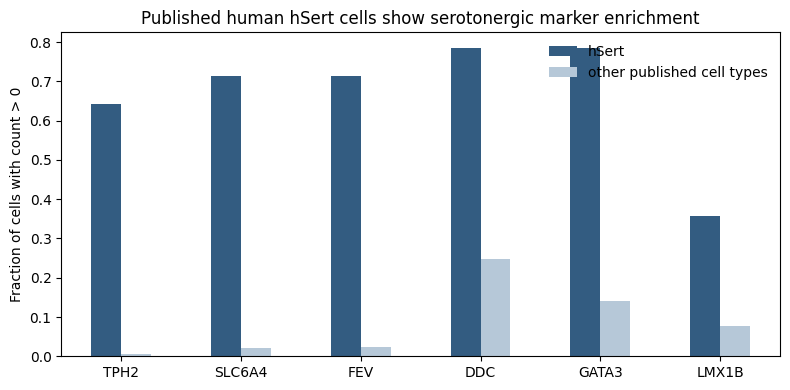

In [5]:
ax = marker_detection.plot.bar(figsize=(8, 4), color=['#335c81', '#b6c8d8'])
ax.set_ylabel('Fraction of cells with count > 0')
ax.set_xlabel('')
ax.set_title('Published human hSert cells show serotonergic marker enrichment')
ax.legend(['hSert', 'other published cell types'], frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Takeaways

1. **Use GSE76381 as an independent positive control.** Its structure and labels are reproducible, and canonical serotonergic markers separate `hSert` from other cells.
2. **Do not fit a probability calibration solely on this dataset.** Fourteen positive cells across three embryos create high sampling uncertainty and limited stage coverage.
3. **Do not call GSE226494 a labeled benchmark yet.** Its 10x count matrices are valid, but published barcode-level ISN labels are missing from the public artifacts inspected.
4. **Next gate:** obtain the zebrafish barcode metadata (preferably from the authors), add biologically distinct neuronal negatives, and reserve independent examples for final evaluation.
